**1. Импорт и загрузка данных**

In [9]:
# Подключение библиотек
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
from statsmodels.graphics.tsaplots import plot_acf
from scipy import stats

In [10]:
# Чтение датасетов

train_df = pd.read_csv("/content/sample_data/data_train.csv")
train_target = pd.read_csv("/content/sample_data/target_train.csv")

test_df = pd.read_csv("/content/sample_data/data_test_small.csv")
test_target = pd.read_csv("/content/sample_data/target_test_small.csv")

In [11]:
# Подготовка временных признаков и колонок

train_df["datetime"] = pd.to_datetime(train_df["datetime"])
test_df["datetime"] = pd.to_datetime(test_df["datetime"])

train_target["Дата"] = pd.to_datetime(train_target["Дата"])
test_target["Дата"] = pd.to_datetime(test_target["Дата"])

train_target = train_target.rename(columns={"Дата": "datetime"})
test_target = test_target.rename(columns={"Дата": "datetime"})

train_df = train_df.sort_values("datetime").reset_index(drop=True)
train_target = train_target.sort_values("datetime").reset_index(drop=True)

test_df = test_df.sort_values("datetime").reset_index(drop=True)
test_target = test_target.sort_values("datetime").reset_index(drop=True)

In [12]:
display(train_df.head())
display(train_target.head())

,datetime,telemetry_0,telemetry_1,telemetry_2,telemetry_3,telemetry_4,telemetry_5,telemetry_6,telemetry_7,telemetry_8,telemetry_9,telemetry_10,telemetry_11,telemetry_12,telemetry_13,telemetry_14,telemetry_15
0,2019-03-01 00:01:00,0.737538,0.478367,0.292816,0.644016,0.919471,0.884814,0.754800,0.413295,0.47192,0.677801,0.687535,0.498407,NaN,NaN,NaN,NaN
1,2019-03-01 00:02:00,0.738406,0.478977,0.292816,0.648557,0.919471,0.887129,0.752977,0.413295,0.47192,0.677801,0.688926,0.498407,NaN,NaN,NaN,NaN
2,2019-03-01 00:03:00,0.738985,0.478977,0.292816,0.647164,0.919471,0.887129,0.755444,0.413295,0.47192,0.677801,0.690316,0.498407,NaN,NaN,NaN,NaN
3,2019-03-01 00:04:00,0.739563,0.478977,0.292816,0.636938,0.919471,0.887129,0.754800,0.413295,0.47192,0.678079,0.692820,0.498407,NaN,NaN,NaN,NaN
4,2019-03-01 00:05:00,0.740431,0.477119,0.292816,0.635834,0.919471,0.887707,0.754156,0.413295,0.47192,0.678357,0.695601,0.498407,NaN,NaN,NaN,NaN


,datetime,target
0,2019-03-13 17:00:00,0.123711
1,2019-03-13 21:00:00,0.319588
2,2019-03-14 01:00:00,0.255155
3,2019-03-14 05:00:00,0.319588
4,2019-03-14 09:00:00,0.159794


In [13]:
print("▶", train_df.columns.tolist())
print("▶", train_target.columns.tolist())

▶ ['datetime', 'telemetry_0', 'telemetry_1', 'telemetry_2', 'telemetry_3', 'telemetry_4', 'telemetry_5', 'telemetry_6', 'telemetry_7', 'telemetry_8', 'telemetry_9', 'telemetry_10', 'telemetry_11', 'telemetry_12', 'telemetry_13', 'telemetry_14', 'telemetry_15']
▶ ['datetime', 'target']


**2. EDA**

In [14]:
# Работа с телеметрическими признаками

telemetry_cols = [col for col in train_df.columns if col.startswith("telemetry_")]
telemetry_cols

['telemetry_0',
 'telemetry_1',
 'telemetry_2',
 'telemetry_3',
 'telemetry_4',
 'telemetry_5',
 'telemetry_6',
 'telemetry_7',
 'telemetry_8',
 'telemetry_9',
 'telemetry_10',
 'telemetry_11',
 'telemetry_12',
 'telemetry_13',
 'telemetry_14',
 'telemetry_15']

In [15]:
# Анализ пропущенных значений

missing_train = train_df.isna().mean().sort_values(ascending=False)
missing_test = test_df.isna().mean().sort_values(ascending=False)

print("▶", "Пропуски в train:")
display(missing_train)

print("▶", "Пропуски в test:")
display(missing_test)

▶ Пропуски в train:


,0
telemetry_12,0.993434
telemetry_14,0.993434
telemetry_13,0.993434
telemetry_15,0.993434
telemetry_4,0.000416
telemetry_5,0.000053
telemetry_0,0.000053
telemetry_7,0.000050
telemetry_1,0.000050
telemetry_11,0.000050


▶ Пропуски в test:


,0
telemetry_12,0.992039
telemetry_14,0.992039
telemetry_13,0.992039
telemetry_15,0.992039
telemetry_7,0.000025
telemetry_0,0.000025
telemetry_1,0.000025
telemetry_2,0.000025
telemetry_3,0.000025
telemetry_11,0.000025


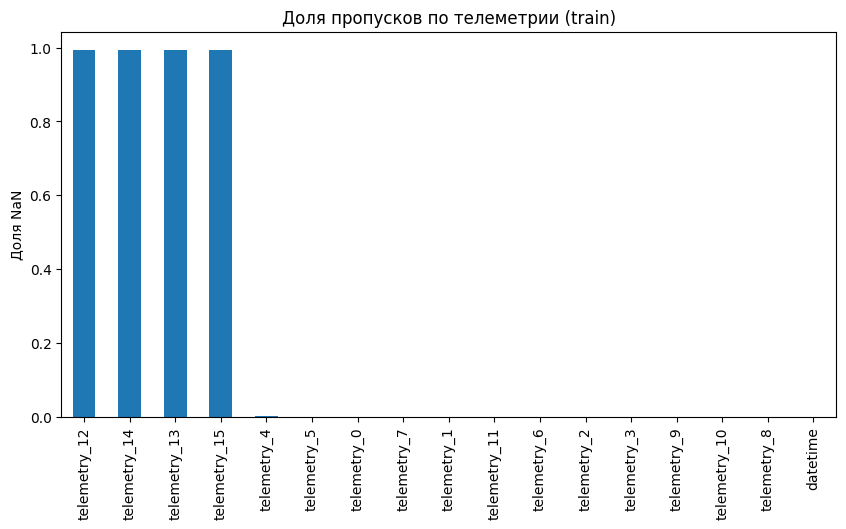

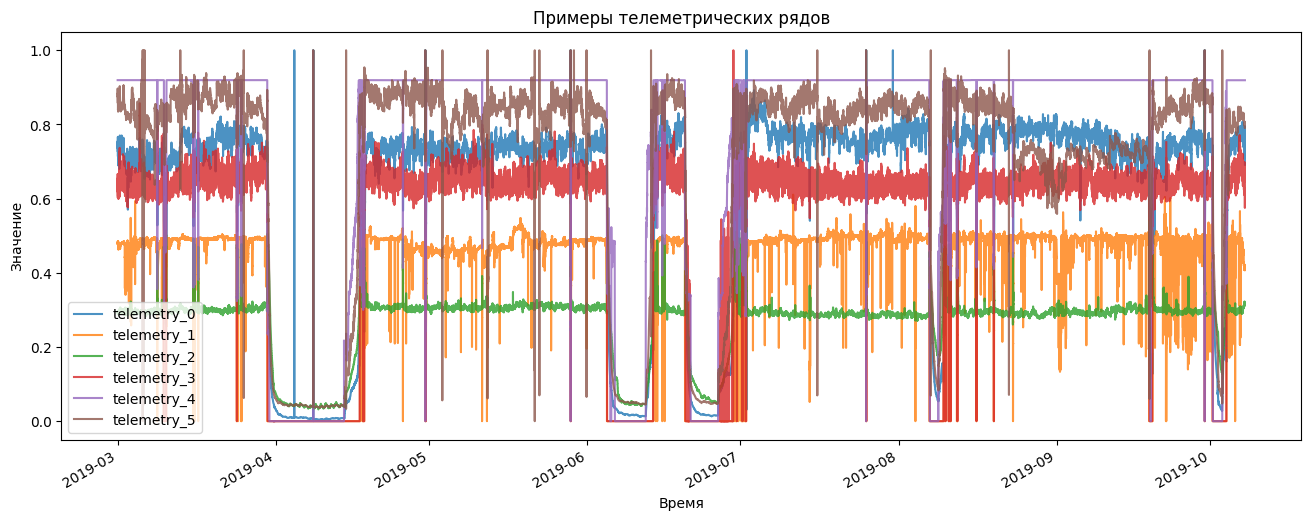

In [16]:
plt.figure(figsize=(10, 5))
missing_train.plot(kind="bar")
plt.title("Доля пропусков по телеметрии (train)")
plt.ylabel("Доля NaN")
plt.show()

sample_cols = telemetry_cols[:6]

train_df.set_index("datetime")[sample_cols].plot(figsize=(16, 6), alpha=0.8)
plt.title("Примеры телеметрических рядов")
plt.xlabel("Время")
plt.ylabel("Значение")
plt.show()

In [17]:
display(train_df[telemetry_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
telemetry_0,319529.0,0.609997,0.276324,0.003472,0.687771,0.738985,0.768498,1.000000
telemetry_1,319530.0,0.379998,0.197845,0.000000,0.431430,0.486093,0.494401,0.610826
telemetry_2,319530.0,0.266786,0.088145,0.031828,0.285872,0.295710,0.304679,1.000000
telemetry_3,319530.0,0.520080,0.259314,0.000000,0.617462,0.639479,0.658350,1.000000
telemetry_4,319413.0,0.762045,0.325663,0.000000,0.919214,0.919471,0.919471,1.000000
telemetry_5,319529.0,0.695864,0.284229,0.000000,0.716705,0.829549,0.863402,1.000000
telemetry_6,319530.0,0.594029,0.300451,0.000000,0.700847,0.749222,0.759198,1.000000
telemetry_7,319530.0,0.522708,0.252911,0.020644,0.366226,0.410817,0.492155,1.000000
telemetry_8,319530.0,0.469582,0.023767,0.344030,0.454270,0.467869,0.482336,1.000000
telemetry_9,319530.0,0.535833,0.254748,0.000000,0.391050,0.581846,0.728682,1.000000


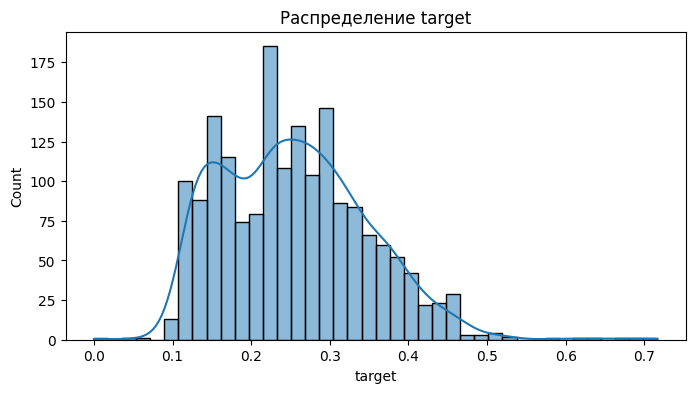

In [18]:
# Анализ целевой переменной

plt.figure(figsize=(8, 4))
sns.histplot(train_target["target"], bins=40, kde=True)
plt.title("Распределение target")
plt.show()

In [19]:
# Интервалы между измерениями

train_target["delta"] = train_target["datetime"].diff().dt.total_seconds() / 60
test_target["delta"] = test_target["datetime"].diff().dt.total_seconds() / 60

In [20]:
print("▶", "Train target интервалы:")
display(train_target["delta"].describe())

print("▶", "Test target интервалы:")
display(test_target["delta"].describe())

▶ Train target интервалы:


,delta
count,1772.000000
mean,169.164786
std,784.088290
min,60.000000
25%,120.000000
50%,120.000000
75%,120.000000
max,26430.000000


▶ Test target интервалы:


,delta
count,317.000000
mean,124.542587
std,60.206887
min,120.000000
25%,120.000000
50%,120.000000
75%,120.000000
max,1080.000000


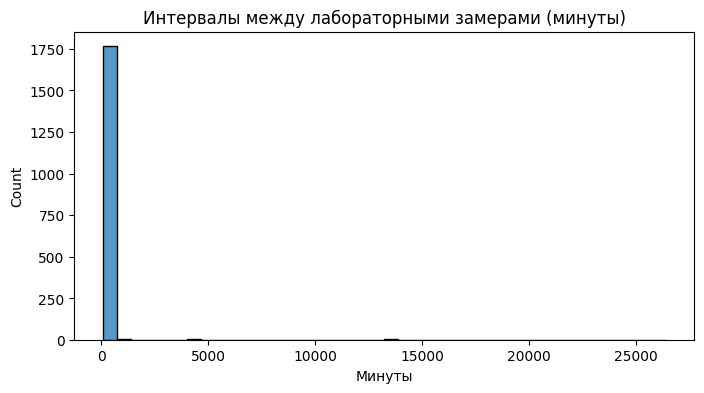

In [21]:
plt.figure(figsize=(8, 4))
sns.histplot(train_target["delta"].dropna(), bins=40, kde=False)
plt.title("Интервалы между лабораторными замерами (минуты)")
plt.xlabel("Минуты")
plt.show()

In [22]:
# синхронизируем телеметрию и таргета с учётом задержки

"""
По условию лабораторный результат приходит с задержкой около 10–15 минут.
Значит, измерение target, зафиксированное в момент t, вероятно относится к состоянию печи в момент t - delay.
"""

def build_aligned_dataset(data_df, target_df, delay_minutes=10):
    data_df = data_df.copy().sort_values("datetime")
    target_df = target_df.copy().sort_values("datetime")

    target_df["aligned_time"] = target_df["datetime"] - pd.Timedelta(minutes=delay_minutes)

    merged = pd.merge_asof(
        target_df.sort_values("aligned_time"),
        data_df.sort_values("datetime"),
        left_on="aligned_time",
        right_on="datetime",
        direction="backward"
    )

    return merged

In [23]:
train_base = build_aligned_dataset(train_df, train_target, delay_minutes=10)
test_base = build_aligned_dataset(test_df, test_target, delay_minutes=10)

In [25]:
# корреляционный анализ с лагами

def lag_corr_table(df, feature_cols, target_col="target", max_lag=15):
    result = []

    for col in feature_cols:
        for lag in range(1, max_lag + 1):
            corr = df[col].shift(lag).corr(df[target_col])
            result.append({
                "feature": col,
                "lag": lag,
                "corr": corr,
                "abs_corr": abs(corr) if pd.notna(corr) else np.nan
            })

    return pd.DataFrame(result)

In [26]:
lag_corrs = lag_corr_table(train_base, telemetry_cols, target_col="target", max_lag=15)
display(lag_corrs.sort_values("abs_corr", ascending=False).head(20))

,feature,lag,corr,abs_corr
47,telemetry_3,3,-0.160294,0.160294
46,telemetry_3,2,-0.159596,0.159596
45,telemetry_3,1,-0.156570,0.156570
0,telemetry_0,1,-0.147754,0.147754
62,telemetry_4,3,-0.142978,0.142978
48,telemetry_3,4,-0.133507,0.133507
141,telemetry_9,7,-0.133367,0.133367
114,telemetry_7,10,-0.131577,0.131577
142,telemetry_9,8,-0.131027,0.131027
112,telemetry_7,8,-0.123489,0.123489


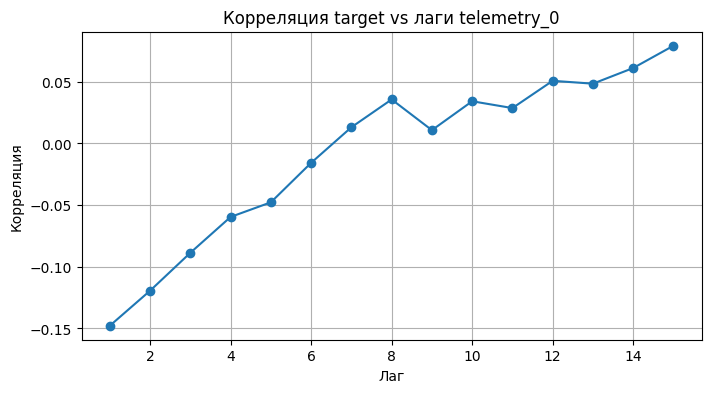

In [27]:
feature_example = "telemetry_0"

tmp = lag_corrs[lag_corrs["feature"] == feature_example]

plt.figure(figsize=(8, 4))
plt.plot(tmp["lag"], tmp["corr"], marker="o")
plt.title(f"Корреляция target vs лаги {feature_example}")
plt.xlabel("Лаг")
plt.ylabel("Корреляция")
plt.grid(True)
plt.show()

In [28]:
# Анализ пропущенных значений и аномалии

high_nan_cols = missing_train[missing_train > 0.95].index.tolist()
high_nan_cols

['telemetry_12', 'telemetry_14', 'telemetry_13', 'telemetry_15']

In [29]:
telemetry_used = [col for col in telemetry_cols if col not in high_nan_cols]
telemetry_used

['telemetry_0',
 'telemetry_1',
 'telemetry_2',
 'telemetry_3',
 'telemetry_4',
 'telemetry_5',
 'telemetry_6',
 'telemetry_7',
 'telemetry_8',
 'telemetry_9',
 'telemetry_10',
 'telemetry_11']

In [30]:
train_df = train_df[["datetime"] + telemetry_used].copy()
test_df = test_df[["datetime"] + telemetry_used].copy()

In [31]:
train_base = build_aligned_dataset(train_df, train_target, delay_minutes=10)
test_base = build_aligned_dataset(test_df, test_target, delay_minutes=10)

**3. Feature Engineering**

In [32]:
# генерация признаков для телеметрии

def make_telemetry_features(data_df, feature_cols, lags=(1,2,3,5,10,15), windows=(5,15,30)):
    df = data_df.copy().sort_values("datetime")

    for col in feature_cols:
        # лаги
        for lag in lags:
            df[f"{col}_lag_{lag}"] = df[col].shift(lag)

        # rolling statistics
        for w in windows:
            df[f"{col}_roll_mean_{w}"] = df[col].rolling(w).mean()
            df[f"{col}_roll_std_{w}"] = df[col].rolling(w).std()
            df[f"{col}_roll_min_{w}"] = df[col].rolling(w).min()
            df[f"{col}_roll_max_{w}"] = df[col].rolling(w).max()

        # производная
        df[f"{col}_diff_1"] = df[col].diff(1)
        df[f"{col}_diff_5"] = df[col].diff(5)

    return df

In [33]:
data_train_feat = make_telemetry_features(train_df, telemetry_used)
data_test_feat = make_telemetry_features(test_df, telemetry_used)

In [34]:
# Синхронизируем таргет с фичами

train_df = build_aligned_dataset(data_train_feat, train_target, delay_minutes=10)
test_df = build_aligned_dataset(data_test_feat, test_target, delay_minutes=10)

In [35]:
print("▶", train_df.shape, test_df.shape)

▶ (1773, 257) (318, 257)


In [36]:
train_df = train_df.rename(columns={"datetime_x": "target_datetime", "datetime_y": "telemetry_datetime"})
test_df = test_df.rename(columns={"datetime_x": "target_datetime", "datetime_y": "telemetry_datetime"})

In [37]:
display(train_df.head())

,target_datetime,target,delta,aligned_time,telemetry_datetime,telemetry_0,telemetry_1,telemetry_2,telemetry_3,telemetry_4,...,telemetry_11_roll_mean_15,telemetry_11_roll_std_15,telemetry_11_roll_min_15,telemetry_11_roll_max_15,telemetry_11_roll_mean_30,telemetry_11_roll_std_30,telemetry_11_roll_min_30,telemetry_11_roll_max_30,telemetry_11_diff_1,telemetry_11_diff_5
0,2019-03-13 17:00:00,0.123711,NaN,2019-03-13 16:50:00,2019-03-13 16:50:00,0.787016,0.503916,0.308730,0.634465,0.919471,...,0.648059,0.000246,0.647763,0.648597,0.647651,0.000504,0.646650,0.648597,0.000000,0.000556
1,2019-03-13 21:00:00,0.319588,240.0,2019-03-13 20:50:00,2019-03-13 20:50:00,0.781807,0.497651,0.302364,0.646688,0.919471,...,0.629425,0.000267,0.628850,0.629684,0.628915,0.000614,0.628016,0.629684,0.000000,0.000278
2,2019-03-14 01:00:00,0.255155,240.0,2019-03-14 00:50:00,2019-03-14 00:50:00,0.785858,0.497651,0.300339,0.640505,0.919471,...,0.642608,0.000144,0.642478,0.642756,0.642599,0.000140,0.642478,0.642756,-0.000278,-0.000278
3,2019-03-14 05:00:00,0.319588,240.0,2019-03-14 04:50:00,2019-03-14 04:50:00,0.749690,0.490207,0.298892,0.647043,0.919471,...,0.611365,0.000704,0.610493,0.612162,0.612524,0.001347,0.610493,0.614665,0.000000,-0.000278
4,2019-03-14 09:00:00,0.159794,240.0,2019-03-14 08:50:00,2019-03-14 08:50:00,0.767051,0.492930,0.301496,0.666986,0.919471,...,0.581865,0.000685,0.581012,0.582402,0.582996,0.001344,0.581012,0.585184,0.000000,-0.000278


In [38]:
# Подготовка выборок

drop_cols = ["target_datetime", "aligned_time", "telemetry_datetime", "target", "delta"]
feature_cols = [col for col in train_df.columns if col not in drop_cols]

In [39]:
feature_cols = [col for col in train_df.columns if col not in ["target_datetime", "aligned_time", "telemetry_datetime", "target", "delta"]]

In [40]:
X_train = train_df[feature_cols].copy()
y_train = train_df["target"].copy()

X_test = test_df[feature_cols].copy()
y_test = test_df["target"].copy()

**4. Метрики**

In [41]:
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    eps = 1e-8
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100

def wape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    eps = 1e-8
    return np.sum(np.abs(y_true - y_pred)) / np.maximum(np.sum(np.abs(y_true)), eps) * 100

def direction_accuracy(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    true_diff = np.sign(np.diff(y_true))
    pred_diff = np.sign(np.diff(y_pred))

    return np.mean(true_diff == pred_diff)

def regression_metrics(y_true, y_pred):
    return pd.Series({
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE_%": mape(y_true, y_pred),
        "WAPE_%": wape(y_true, y_pred),
        "Direction_Accuracy": direction_accuracy(y_true, y_pred)
    })

In [42]:
# Модель 1 - Ridge

ridge_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)

ridge_metrics = regression_metrics(y_test, ridge_pred)
ridge_metrics

,0
MAE,0.064515
RMSE,0.078902
MAPE_%,37.026295
WAPE_%,30.765145
Direction_Accuracy,0.548896


In [43]:
# Random Forest

rf_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_metrics = regression_metrics(y_test, rf_pred)
rf_metrics

,0
MAE,0.062664
RMSE,0.078067
MAPE_%,34.266288
WAPE_%,29.882136
Direction_Accuracy,0.504732


In [44]:
# SARIMAX

sarimax_feature_cols = telemetry_used.copy()

sarimax_train = train_base.copy()
sarimax_test = test_base.copy()

sarimax_train = sarimax_train.rename(columns={"datetime_x": "target_datetime", "datetime_y": "telemetry_datetime"})
sarimax_test = sarimax_test.rename(columns={"datetime_x": "target_datetime", "datetime_y": "telemetry_datetime"})

In [45]:
X_train_sarimax = sarimax_train[sarimax_feature_cols].copy()
y_train_sarimax = sarimax_train["target"].copy()

X_test_sarimax = sarimax_test[sarimax_feature_cols].copy()
y_test_sarimax = sarimax_test["target"].copy()

In [46]:
imputer = SimpleImputer(strategy="median")
X_train_sarimax_imp = pd.DataFrame(
    imputer.fit_transform(X_train_sarimax),
    columns=X_train_sarimax.columns,
    index=X_train_sarimax.index
)

X_test_sarimax_imp = pd.DataFrame(
    imputer.transform(X_test_sarimax),
    columns=X_test_sarimax.columns,
    index=X_test_sarimax.index
)

In [47]:
sarimax_model = SARIMAX(
    endog=y_train_sarimax,
    exog=X_train_sarimax_imp,
    order=(1, 0, 1),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_res = sarimax_model.fit(disp=False)
sarimax_pred = sarimax_res.predict(
    start=len(y_train_sarimax),
    end=len(y_train_sarimax) + len(y_test_sarimax) - 1,
    exog=X_test_sarimax_imp
)

sarimax_metrics = regression_metrics(y_test_sarimax, sarimax_pred)
sarimax_metrics

,0
MAE,0.068688
RMSE,0.082815
MAPE_%,40.095708
WAPE_%,32.754774
Direction_Accuracy,0.517350


In [48]:
results = pd.DataFrame({
    "Ridge": ridge_metrics,
    "RandomForest": rf_metrics,
    "SARIMAX": sarimax_metrics
}).T

results.sort_values("RMSE")

,MAE,RMSE,MAPE_%,WAPE_%,Direction_Accuracy
RandomForest,0.062664,0.078067,34.266288,29.882136,0.504732
Ridge,0.064515,0.078902,37.026295,30.765145,0.548896
SARIMAX,0.068688,0.082815,40.095708,32.754774,0.517350


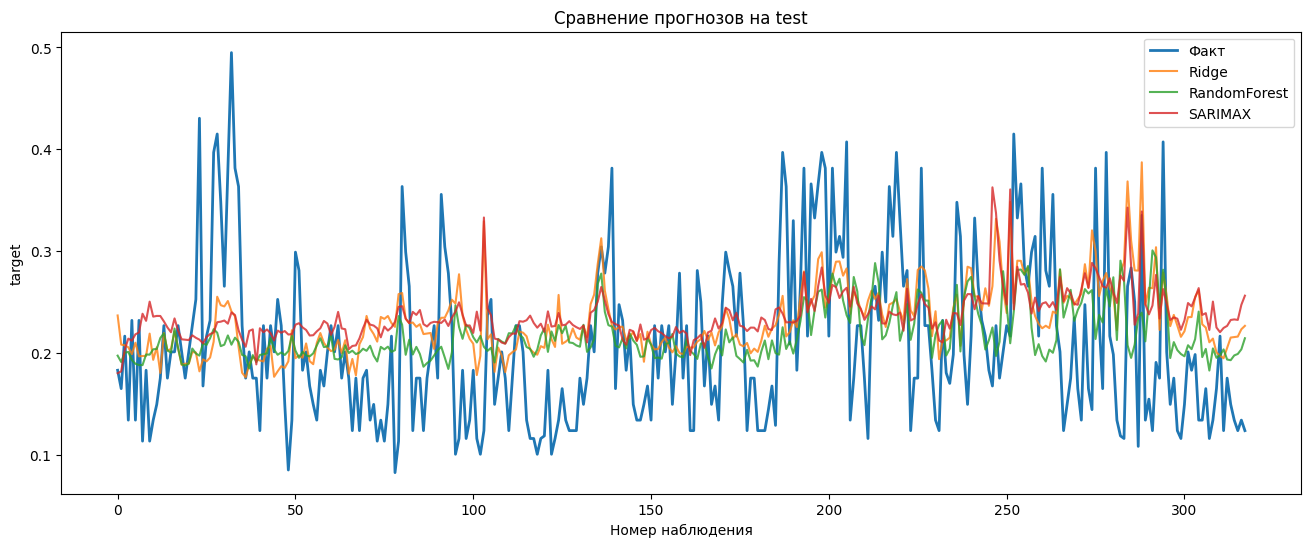

In [49]:
plt.figure(figsize=(16, 6))
plt.plot(y_test.values, label="Факт", linewidth=2)
plt.plot(ridge_pred, label="Ridge", alpha=0.8)
plt.plot(rf_pred, label="RandomForest", alpha=0.8)
plt.plot(np.array(sarimax_pred), label="SARIMAX", alpha=0.8)
plt.title("Сравнение прогнозов на test")
plt.xlabel("Номер наблюдения")
plt.ylabel("target")
plt.legend()
plt.show()

In [50]:
# анализ остатков

best_pred = rf_pred
residuals = y_test - best_pred

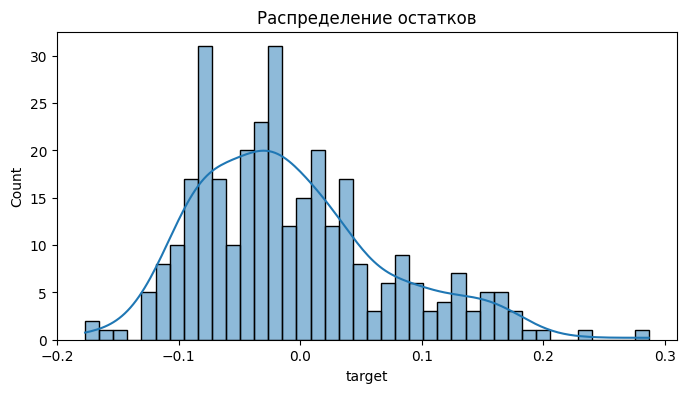

In [51]:
plt.figure(figsize=(8, 4))
sns.histplot(residuals, bins=40, kde=True)
plt.title("Распределение остатков")
plt.show()

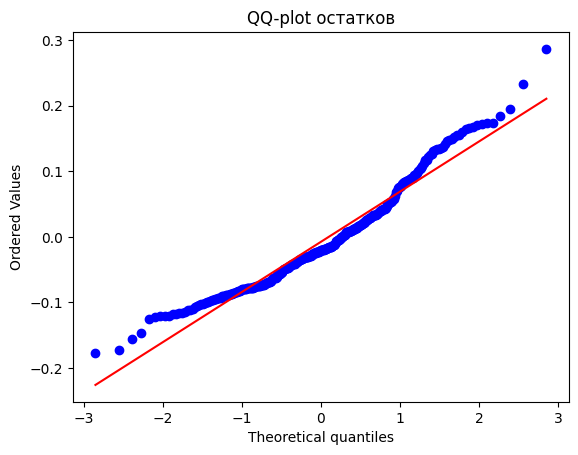

In [52]:
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ-plot остатков")
plt.show()

In [53]:
shapiro_sample = residuals.sample(min(500, len(residuals)), random_state=42)
shapiro_test = stats.shapiro(shapiro_sample)

print("▶", "Shapiro-Wilk statistic:", shapiro_test.statistic)
print("▶", "p-value:", shapiro_test.pvalue)

▶ Shapiro-Wilk statistic: 0.9569546156123727
▶ p-value: 4.698439623978223e-08


<Figure size 1000x400 with 0 Axes>

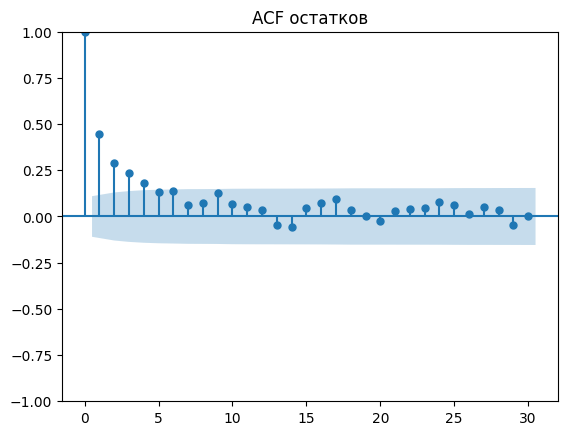

In [54]:
# Автокорреляция остатков

plt.figure(figsize=(10, 4))
plot_acf(residuals, lags=30)
plt.title("ACF остатков")
plt.show()

In [55]:
lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
lb_test

,lb_stat,lb_pvalue
10,140.696703,3.033507e-25


In [56]:
# Гетероскедастичность

X_bp = SimpleImputer(strategy="median").fit_transform(X_test)
bp_test = het_breuschpagan(residuals, X_bp)

bp_labels = ["LM Stat", "LM p-value", "F Stat", "F p-value"]
pd.Series(bp_test, index=bp_labels)

,0
LM Stat,183.162346
LM p-value,0.999555
F Stat,1.349848
F p-value,0.029956


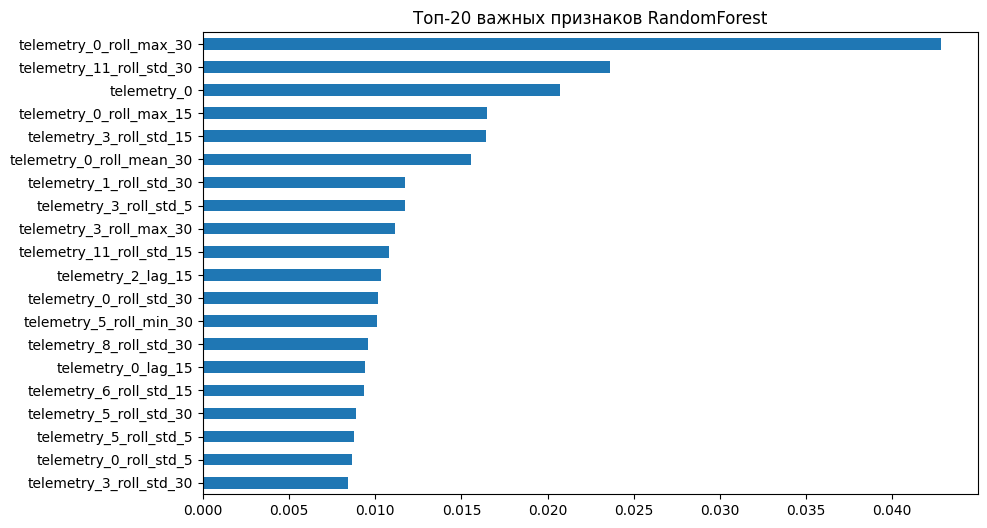

In [57]:
# Важность признаков

rf_estimator = rf_model.named_steps["model"]

importances = pd.Series(rf_estimator.feature_importances_, index=X_train.columns)
top_importances = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
top_importances.sort_values().plot(kind="barh")
plt.title("Топ-20 важных признаков RandomForest")
plt.show()

In [58]:
# Подбор задержки 10-15 минут

def run_simple_delay_experiment(delay):
    train_base_local = build_aligned_dataset(train_df, train_target, delay_minutes=delay)
    test_base_local = build_aligned_dataset(test_df, test_target, delay_minutes=delay)

    data_train_feat_local = make_telemetry_features(train_df, telemetry_used)
    data_test_feat_local = make_telemetry_features(test_df, telemetry_used)

    train_df_local = build_aligned_dataset(data_train_feat_local, train_target, delay_minutes=delay)
    test_df_local = build_aligned_dataset(data_test_feat_local, test_target, delay_minutes=delay)

    train_df_local = train_df_local.rename(columns={"datetime_x": "target_datetime", "datetime_y": "telemetry_datetime"})
    test_df_local = test_df_local.rename(columns={"datetime_x": "target_datetime", "datetime_y": "telemetry_datetime"})

    feature_cols_local = [col for col in train_df_local.columns if col not in ["target_datetime", "aligned_time", "telemetry_datetime", "target", "delta"]]

    X_tr = train_df_local[feature_cols_local]
    y_tr = train_df_local["target"]
    X_te = test_df_local[feature_cols_local]
    y_te = test_df_local["target"]

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", Ridge(alpha=1.0))
    ])

    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)

    metrics = regression_metrics(y_te, pred)
    metrics["delay"] = delay
    return metrics

In [59]:
delay_results = pd.DataFrame([run_simple_delay_experiment(d) for d in [10, 12, 15]])
delay_results

KeyError: 'datetime'